> 이전 실험 기록입니다. 현재 방식은 뉴스 점수를 입력 feature로 사용하는 `03_6_news_feature_ensemble.ipynb`이며, 이 노트북의 잔차 계수는 현재 선택에 사용하지 않습니다.

# 지정 앙상블 + 방향 유지 Jev 뉴스: 2022~2023 선택, 2024~2026 평가

5일 **NLinear+XGBoost**, 20일 **NLinear+DLinear**, 60일 **DLinear**를 검증한다. 가격은 동일 가중 산술평균하며 Naive/Persistence와 오차상관 필터는 사용하지 않는다. 각 구성 단일 모델에도 같은 뉴스 보정을 적용해 앙상블 효과와 뉴스 효과를 구분한다. 원래 모델 순위는 특정 Validation 구간의 결과이며 다른 기간의 우위를 가정하지 않는다.

뉴스는 네 클래스의 **단독 최고 확률**이 bullish면 +1, bearish면 −1, neutral/uncertain 또는 동률이면 0이다. `기사 신호 = 방향 × relevance × confidence`. 기존의 비음수 최근성/시차 가중치와 tanh 합계를 재사용한다. 가격 보정은 `P_adj = P_base × exp(beta_h × 과거 20일 일수익률 표준편차 × √h × 뉴스지수)`다. beta의 **초기값은 0.5, 범위는 [0,1]**이며 초기값은 양의 최종 계수를 강제하지 않는다. 경계 0도 학습 결과로 허용한다.

**시간순 절차:** ① 2022년 out-of-sample 예측으로 모델별 설정과 첫 뉴스 계수 적합 → ② 고정 계수로 2023년 비교·모델/뉴스 사용 여부 선택 → ③ 선택을 유지하고 뉴스 계수를 2022~2023년 전체 정답으로 재적합 → ④ 가격 모델을 2015~2023년까지 재학습해 2024~2026년 전체에 고정 적용. 정답이 2023년 말 이후인 사례는 어떤 계수/모델 적합에도 쓰지 않는다. 비교 점수는 `RMSE/단일 최저 RMSE + (1−균형 정확도)/(1−단일 최고 균형 정확도)`로 동등 가중한다. 동률이면 뉴스 없음·구성원 적음을 우선한다. 뉴스 초기값 0.5 고정은 진단용이며 선택 후보가 아니다.

**해석 범위:** 2024~2025는 이미 살펴본 과거 자료다. 2026년도 9월 25일까지 관측된 가격 중 정답이 성숙한 예측만 평가한다. Jev 분류는 2026년에 수행한 소급 분석이므로 당시 실시간 성능이 아니다. 원자료 수집 시각·수정 가능성과 기사 선정 정책 차이도 남는다. 본 실험은 운영 artifact·DB·배포를 교체하지 않는다.

In [1]:
import os, sys, json, hashlib, tempfile, platform, time
from pathlib import Path
for key in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","VECLIB_MAXIMUM_THREADS"):
    os.environ[key]="1"
os.environ.setdefault("MPLCONFIGDIR",str(Path(tempfile.gettempdir())/"coffee-matplotlib"))
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Markdown, display
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/"coffee_service").is_dir())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
from data_code.fixed_ensemble_news import (PAIRS, SEED, FINAL_CUTOFF, scores, average_prices, align_models,
    adjust, fit_strength, load_market, fixed_features, build_features, forecast, paired_interval)
from coffee_service.news_residual import signal_features, SIGNAL_DEFINITION, LAGS, LAG_WEIGHTS
from coffee_service.transform import coffee_sessions
FONT={"Darwin":"AppleGothic","Windows":"Malgun Gothic"}.get(platform.system(),"NanumGothic")
assert FONT in {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({"font.family":FONT,"axes.unicode_minus":False,"figure.dpi":110,
                    "axes.spines.top":False,"axes.spines.right":False})
def show(frame,digits=4):display(Markdown(frame.to_markdown(index=False,floatfmt=f".{digits}f")))
SOURCE=ROOT/"data/processed/fixed_ensemble_news/sources_20260928"
CACHE=ROOT/"data/processed/single_model_comparison/20260926T115735770501Z/individual_predictions.parquet"
NEWS=ROOT/"data/jev/sentiment.csv"
inputs=[*sorted(SOURCE.glob("*.parquet")),CACHE,NEWS,
        ROOT/"data_code/fixed_ensemble_news.py",ROOT/"coffee_service/news_residual.py",
        ROOT/"data_code/single_model_networks.py",ROOT/"coffee_service/transform.py",
        ROOT/"coffee_service/features.py",ROOT/"coffee_service/training.py"]
hashes={str(p.relative_to(ROOT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in inputs}
notebook=json.loads((ROOT/"data_code/03_5_fixed_ensemble_news.ipynb").read_text())
code="\n".join("".join(c["source"]) for c in notebook["cells"] if c["cell_type"]=="code")
hashes["notebook_code"]=hashlib.sha256(code.encode()).hexdigest()
versions={name:version(name) for name in ("numpy","pandas","scipy","scikit-learn","torch","xgboost")}
versions["python"]=platform.python_version()
RUN=hashlib.sha256(json.dumps([hashes,versions],sort_keys=True).encode()).hexdigest()[:16]
OUTPUT=ROOT/"data/processed/fixed_ensemble_news"/RUN
OUTPUT.mkdir(parents=True,exist_ok=True)
print("연구 결과:",OUTPUT.relative_to(ROOT),"| 신호:",SIGNAL_DEFINITION)

연구 결과: data/processed/fixed_ensemble_news/a0b224ef6e71cbae | 신호: argmax_direction_times_relevance_confidence


## 1. 가격·기후·거시경제 입력 확인

자료 경로는 과거 원본을 보존한 연구용 복사본이다. 2025년까지의 가격/거시는 기존 snapshot, 이후는 `jev_live`의 추가 관측 자료를 이어 붙였다. NASA 6지역의 누락된 2026-01-31~09-25 관측은 기존 `ingestion.fetch_weather`로 추가 수집했다. 새 API 요청 없이 아래 셀을 재실행할 수 있다. 기후 공개 지연 4일, ALFRED 공개일+1일 규칙을 유지한다. NASA 자료의 실제 과거 배포 snapshot을 보유한 것은 아니다.

**수집한 모든 컬럼을 쓰지는 않는다.** 기존 27개 입력을 유지해 이전 단일 모델 비교와 연결한다. 6지역 강수·평균기온은 사용하고, 최저기온 기반 브라질 서리 6개는 최초 학습에서 상수라 제외한다. 최고기온·습도는 기존 피처 설계에 없으며, 광의 달러지수와 COT는 기존 시점 계약 문제로 제외했다. 이것은 모든 후보 변수를 최적화했다는 뜻이 아니다.

In [2]:
sources,sessions,prices=load_market(SOURCE)
FEATURES,constant=fixed_features(sources,sessions)
assert len(FEATURES)==27
show(pd.DataFrame([{"자료":name,"시작":d.date.min().date(),"끝":d.date.max().date(),"행 수":len(d)} for name,d in sources.items()]),0)
feature_audit=pd.DataFrame([
    {"입력":"가격","상태":"사용","내용":"1/5/20일 로그수익률·20일 변동성","개수":4},
    {"입력":"거시경제","상태":"사용","내용":"ALFRED DEXBZUS 환율·DFF 금리·DCOILWTICO 유가의 20일 변화","개수":3},
    {"입력":"6지역 기후","상태":"사용","내용":"강수 편차·평균기온 편차·가뭄","개수":18},
    {"입력":"달력","상태":"사용","내용":"월 sin/cos","개수":2},
    {"입력":"브라질 최저기온 파생","상태":"제외: 최초 학습 상수","내용":"서리·가뭄×서리","개수":6},
    {"입력":"NASA 최고기온·습도","상태":"미사용","내용":"기존 피처 정의에 없음","개수":12},
    {"입력":"DTWEXBGS·COT","상태":"미사용","내용":"기존 공개 시점/소급 자료 계약의 제한","개수":2}])
show(feature_audit,0)
print("사용 피처:",FEATURES,"\n상수 제외:",constant)
volatility=np.log(prices.close).diff().rolling(20,min_periods=20).std(ddof=1)
print("가격 관측 최종일:",prices.close.dropna().index.max().date())

| 자료                    | 시작       | 끝         |   행 수 |
|:------------------------|:-----------|:-----------|--------:|
| coffee                  | 2014-07-01 | 2026-09-25 |    3083 |
| alfred_dexbzus          | 2014-07-01 | 2026-09-18 |    3189 |
| alfred_dff              | 2014-07-01 | 2026-09-24 |    4469 |
| alfred_dcoilwtico       | 2014-07-01 | 2026-09-22 |    3191 |
| weather_br_sul_minas    | 2014-06-01 | 2026-09-25 |    4500 |
| weather_br_cerrado      | 2014-06-01 | 2026-09-25 |    4500 |
| weather_br_alta_mogiana | 2014-06-01 | 2026-09-25 |    4500 |
| weather_co_huila        | 2014-06-01 | 2026-09-25 |    4500 |
| weather_co_caldas       | 2014-06-01 | 2026-09-25 |    4500 |
| weather_co_antioquia    | 2014-06-01 | 2026-09-25 |    4500 |

| 입력                 | 상태                 | 내용                                                     |   개수 |
|:---------------------|:---------------------|:---------------------------------------------------------|-------:|
| 가격                 | 사용                 | 1/5/20일 로그수익률·20일 변동성                          |      4 |
| 거시경제             | 사용                 | ALFRED DEXBZUS 환율·DFF 금리·DCOILWTICO 유가의 20일 변화 |      3 |
| 6지역 기후           | 사용                 | 강수 편차·평균기온 편차·가뭄                             |     18 |
| 달력                 | 사용                 | 월 sin/cos                                               |      2 |
| 브라질 최저기온 파생 | 제외: 최초 학습 상수 | 서리·가뭄×서리                                           |      6 |
| NASA 최고기온·습도   | 미사용               | 기존 피처 정의에 없음                                    |     12 |
| DTWEXBGS·COT         | 미사용               | 기존 공개 시점/소급 자료 계약의 제한                     |      2 |

사용 피처: ['return_1', 'return_5', 'return_20', 'volatility_20', 'brl_change_20', 'rate_change_20', 'oil_change_20', 'br_sul_minas_rain_anomaly', 'br_sul_minas_temp_anomaly', 'br_sul_minas_drought', 'br_cerrado_rain_anomaly', 'br_cerrado_temp_anomaly', 'br_cerrado_drought', 'br_alta_mogiana_rain_anomaly', 'br_alta_mogiana_temp_anomaly', 'br_alta_mogiana_drought', 'co_huila_rain_anomaly', 'co_huila_temp_anomaly', 'co_huila_drought', 'co_caldas_rain_anomaly', 'co_caldas_temp_anomaly', 'co_caldas_drought', 'co_antioquia_rain_anomaly', 'co_antioquia_temp_anomaly', 'co_antioquia_drought', 'month_sin', 'month_cos'] 
상수 제외: ['br_sul_minas_frost', 'br_sul_minas_drought_frost', 'br_cerrado_frost', 'br_cerrado_drought_frost', 'br_alta_mogiana_frost', 'br_alta_mogiana_drought_frost']
가격 관측 최종일: 2026-09-25


## 2. 새 뉴스 신호와 과거 이용 시점

CSV의 최신 연구 선정 행을 사용한다. 전 기간 분석은 2026년에 이루어졌다. 연구 시각은 기사 공개·수정·일별 선정 완료 시각의 보수적 최댓값이며 실제 분류 이용 가능 시각을 소급 변경하지 않는다. 기간별 기사 수·영 신호 수를 공개한다. 2022년 초에는 2021년 기사 이력이 없으므로 첫 한 달을 공통 제외한다. 뉴스가 없는 날에도 이전 기사의 감쇠 기여는 남을 수 있다. neutral·uncertain 0은 그 기사 자체의 기여를 뜻한다.

In [3]:
news=pd.read_csv(NEWS).loc[lambda d:d.selected_for_research.eq(True)].copy()
assert news.is_latest_analysis.all() and not news.content_hash.duplicated().any()
probcols=["p_bullish","p_bearish","p_neutral","p_uncertain"]
prob=news[probcols].to_numpy(float)
assert np.isfinite(prob).all() and ((prob>=0)&(prob<=1)).all()
np.testing.assert_allclose(prob.sum(axis=1),1,atol=.02,rtol=0)
winners=np.isclose(prob,prob.max(axis=1,keepdims=True),atol=1e-8,rtol=0)
news["direction"]=np.where((winners.sum(axis=1)==1)&winners[:,0],1,
    np.where((winners.sum(axis=1)==1)&winners[:,1],-1,0))
news["article_signal"]=news.direction*news.relevance*news.confidence
news["year"]=pd.to_datetime(news.selection_date).dt.year
news_audit=news.groupby("year").agg(기사수=("analysis_id","size"),영신호=("article_signal",lambda s:int(s.eq(0).sum())),
    상승신호=("article_signal",lambda s:int(s.gt(0).sum())),하락신호=("article_signal",lambda s:int(s.lt(0).sum())),제목만=("title_only","sum")).reset_index().rename(columns={"year":"연도"})
show(news_audit,0)
records=[]
for raw in news.to_dict("records"):
    row={k:None if pd.isna(v) else v for k,v in raw.items()}
    event=max(pd.Timestamp(row["event_at"]),pd.Timestamp(row["published_at"]))
    visible=max(event,pd.Timestamp(row["research_available_at"]),pd.Timestamp(row["modified_at"]) if row["modified_at"] else event)
    row["event_at"]=event.isoformat();row["selection_available_at"]=visible.isoformat();records.append(row)
news_sessions=sessions[sessions>=pd.Timestamp("2022-01-01")]
features=signal_features(records,news_sessions,availability="research",signal_definition=SIGNAL_DEFINITION)
live=signal_features(records,news_sessions,availability="live",signal_definition=SIGNAL_DEFINITION)
news_index=pd.Series(features[[f"news_lag_{lag}" for lag in LAGS]].to_numpy()@LAG_WEIGHTS,index=news_sessions)
assert live.news_signal.eq(0).all(),"새 실시간 뉴스가 생겼다면 설명과 시점 비교를 갱신하세요."
print("실제 분류 이용 시각:",news.available_at.min(),"~",news.available_at.max())
def with_news(reference,h):
    r=reference.copy()
    np.testing.assert_allclose(prices.close.reindex(r.index),r.current_price)
    r["news_x"]=(news_index*volatility.reindex(news_sessions)*np.sqrt(h)).reindex(r.index)
    assert np.isfinite(r.news_x).all()
    return r

|   연도 |   기사수 |   영신호 |   상승신호 |   하락신호 |   제목만 |
|-------:|---------:|---------:|-----------:|-----------:|---------:|
|   2022 |      189 |      151 |         30 |          8 |      189 |
|   2023 |      213 |      174 |         25 |         14 |      213 |
|   2024 |      256 |      187 |         47 |         22 |      256 |
|   2025 |      383 |      251 |         83 |         49 |      383 |
|   2026 |      404 |      191 |        120 |         93 |      280 |

실제 분류 이용 시각: 2026-09-26T09:12:42.298569Z ~ 2026-09-27T02:21:29.482870Z


## 3. 2022~2023년에서만 모델·계수 선택

기존 2022/2023년의 out-of-sample 예측을 읽는다. 각 가격 모델은 해당 연도 직전 말까지만 학습했다. 모델별 설정(신경망 10/30 epoch, 트리 100/300개)은 2022년 가격 RMSE로 고정한다. 조합·뉴스 채택은 2023년 RMSE와 균형 정확도로 선택한다. 전체 2022~2023년 재적합 계수를 아래에서 저장한 뒤 평가 구간을 예측한다. 가격 회귀와 뉴스 계수의 학습 기간은 서로 다르다.

|   지평 | 모델    |   설정 |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|-------:|:--------|-------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
|      5 | NLinear |     10 |    226 |      9.7822 |        0.0469 |           53.0973 |           50.1215 |           70.5263 |
|      5 | NLinear |     30 |    226 |     10.0798 |        0.0482 |           52.6549 |           50.4453 |           65.2632 |
|      5 | XGBoost |    100 |    226 |     10.2412 |        0.0487 |           56.1947 |           52.2470 |           74.7368 |
|      5 | XGBoost |    300 |    226 |     10.6997 |        0.0509 |           56.6372 |           53.3401 |           69.4737 |
|     20 | NLinear |     10 |    211 |     17.5822 |        0.0871 |           64.4550 |           58.4211 |           63.1579 |
|     20 | NLinear |     30 |    211 |     19.4103 |        0.0951 |           62.5592 |           57.2271 |           61.8421 |
|     20 | DLinear |     10 |    211 |     23.6014 |        0.1141 |           67.7725 |           62.7388 |           55.2632 |
|     20 | DLinear |     30 |    211 |     26.7882 |        0.1316 |           69.1943 |           65.2875 |           48.6842 |
|     60 | DLinear |     10 |    171 |     21.7987 |        0.1083 |           76.0234 |           65.4781 |           62.2642 |
|     60 | DLinear |     30 |    171 |     22.7520 |        0.1150 |           69.5906 |           50.9434 |           98.1132 |

2022년 설정: {(5, 'NLinear'): 10, (5, 'XGBoost'): 100, (20, 'NLinear'): 10, (20, 'DLinear'): 10, (60, 'DLinear'): 10}


|   지평 | 모델              | 뉴스          |   구성원 수 |   beta |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|-------:|:------------------|:--------------|------------:|-------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
|      5 | NLinear           | 뉴스 없음     |           1 | 0.0000 |    245 |      8.6624 |        0.0503 |           51.4286 |           51.4239 |           48.7395 |
|      5 | NLinear           | 초기 0.5 고정 |           1 | 0.5000 |    245 |      8.8238 |        0.0513 |           51.8367 |           51.8441 |           47.8992 |
|      5 | NLinear           | 뉴스 학습     |           1 | 0.0000 |    245 |      8.6624 |        0.0503 |           51.4286 |           51.4239 |           48.7395 |
|      5 | XGBoost           | 뉴스 없음     |           1 | 0.0000 |    245 |      8.5259 |        0.0494 |           52.2449 |           52.1008 |           52.9412 |
|      5 | XGBoost           | 초기 0.5 고정 |           1 | 0.5000 |    245 |      8.6866 |        0.0504 |           51.0204 |           50.9570 |           51.2605 |
|      5 | XGBoost           | 뉴스 학습     |           1 | 0.0000 |    245 |      8.5259 |        0.0494 |           52.2449 |           52.1008 |           52.9412 |
|      5 | NLinear + XGBoost | 뉴스 없음     |           2 | 0.0000 |    245 |      8.5297 |        0.0495 |           53.0612 |           53.0345 |           47.8992 |
|      5 | NLinear + XGBoost | 초기 0.5 고정 |           2 | 0.5000 |    245 |      8.6918 |        0.0505 |           51.4286 |           51.4472 |           47.8992 |
|      5 | NLinear + XGBoost | 뉴스 학습     |           2 | 0.0000 |    245 |      8.5297 |        0.0495 |           53.0612 |           53.0345 |           47.8992 |
|     20 | NLinear           | 뉴스 없음     |           1 | 0.0000 |    230 |     18.0276 |        0.1054 |           50.0000 |           49.9242 |           48.3333 |
|     20 | NLinear           | 초기 0.5 고정 |           1 | 0.5000 |    230 |     18.1260 |        0.1061 |           50.4348 |           50.3788 |           48.3333 |
|     20 | NLinear           | 뉴스 학습     |           1 | 0.0000 |    230 |     18.0276 |        0.1054 |           50.0000 |           49.9242 |           48.3333 |
|     20 | DLinear           | 뉴스 없음     |           1 | 0.0000 |    230 |     17.5270 |        0.1026 |           53.0435 |           52.9924 |           45.8333 |
|     20 | DLinear           | 초기 0.5 고정 |           1 | 0.5000 |    230 |     17.6466 |        0.1035 |           52.1739 |           52.1212 |           46.6667 |
|     20 | DLinear           | 뉴스 학습     |           1 | 0.0123 |    230 |     17.5294 |        0.1026 |           53.0435 |           52.9924 |           45.8333 |
|     20 | NLinear + DLinear | 뉴스 없음     |           2 | 0.0000 |    230 |     17.7387 |        0.1037 |           51.7391 |           51.6667 |           46.6667 |
|     20 | NLinear + DLinear | 초기 0.5 고정 |           2 | 0.5000 |    230 |     17.8478 |        0.1046 |           51.7391 |           51.6667 |           46.6667 |
|     20 | NLinear + DLinear | 뉴스 학습     |           2 | 0.0000 |    230 |     17.7387 |        0.1037 |           51.7391 |           51.6667 |           46.6667 |
|     60 | DLinear           | 뉴스 없음     |           1 | 0.0000 |    190 |     29.9488 |        0.1794 |           51.5789 |           51.5486 |           48.8636 |
|     60 | DLinear           | 초기 0.5 고정 |           1 | 0.5000 |    190 |     30.2143 |        0.1812 |           51.0526 |           51.0584 |           48.8636 |
|     60 | DLinear           | 뉴스 학습     |           1 | 0.0000 |    190 |     29.9488 |        0.1794 |           51.5789 |           51.5486 |           48.8636 |

|   지평 | 모델              | 뉴스      |   가격 RMSE |   균형 정확도 (%) |   상대 오차 합 |
|-------:|:------------------|:----------|------------:|------------------:|---------------:|
|      5 | NLinear + XGBoost | 뉴스 없음 |      8.5297 |           53.0345 |         1.9809 |
|     20 | DLinear           | 뉴스 없음 |     17.5270 |           52.9924 |         2.0000 |
|     60 | DLinear           | 뉴스 없음 |     29.9488 |           51.5486 |         2.0000 |

|   지평 | 모델              | 적합           |   initial_beta |   beta |   fit_rows | fit_max_target      | path                                                                                                                                 |   gradient_at_zero |
|-------:|:------------------|:---------------|---------------:|-------:|-----------:|:--------------------|:-------------------------------------------------------------------------------------------------------------------------------------|-------------------:|
|      5 | NLinear           | 2022 개발      |         0.5000 | 0.0000 |        226 | 2022-12-30T00:00:00 | [0.5, 0.41743759267245495, 0.0, 0.0]                                                                                                 |             0.0583 |
|      5 | NLinear           | 2022~2023 최종 |         0.5000 | 0.0000 |        471 | 2023-12-29T00:00:00 | [0.5, 0.41779249528208195, 0.0, 0.0]                                                                                                 |             0.0631 |
|      5 | XGBoost           | 2022 개발      |         0.5000 | 0.0000 |        226 | 2022-12-30T00:00:00 | [0.5, 0.433803339094461, 0.0, 0.0]                                                                                                   |             0.0445 |
|      5 | XGBoost           | 2022~2023 최종 |         0.5000 | 0.0000 |        471 | 2023-12-29T00:00:00 | [0.5, 0.42664004074227135, 0.0, 0.0]                                                                                                 |             0.0552 |
|      5 | NLinear + XGBoost | 2022 개발      |         0.5000 | 0.0000 |        226 | 2022-12-30T00:00:00 | [0.5, 0.42343953455538863, 0.0, 0.0]                                                                                                 |             0.0528 |
|      5 | NLinear + XGBoost | 2022~2023 최종 |         0.5000 | 0.0000 |        471 | 2023-12-29T00:00:00 | [0.5, 0.42030656140987566, 0.0, 0.0]                                                                                                 |             0.0605 |
|     20 | NLinear           | 2022 개발      |         0.5000 | 0.0000 |        211 | 2022-12-30T00:00:00 | [0.5, 0.3573035246944915, 0.0, 0.0]                                                                                                  |             0.1108 |
|     20 | NLinear           | 2022~2023 최종 |         0.5000 | 0.0000 |        441 | 2023-12-29T00:00:00 | [0.5, 0.4190402156610325, 0.0, 0.0]                                                                                                  |             0.0606 |
|     20 | DLinear           | 2022 개발      |         0.5000 | 0.0123 |        211 | 2022-12-30T00:00:00 | [0.5, 0.4856879425880594, 0.018732766940369204, 0.01238121535757593, 0.0122962405815937, 0.012296225316817821, 0.012296225316817821] |            -0.0004 |
|     20 | DLinear           | 2022~2023 최종 |         0.5000 | 0.0000 |        441 | 2023-12-29T00:00:00 | [0.5, 0.47873260045528276, 0.0, 0.0]                                                                                                 |             0.0080 |
|     20 | NLinear + DLinear | 2022 개발      |         0.5000 | 0.0000 |        211 | 2022-12-30T00:00:00 | [0.5, 0.43121792961724115, 0.0, 0.0]                                                                                                 |             0.0435 |
|     20 | NLinear + DLinear | 2022~2023 최종 |         0.5000 | 0.0000 |        441 | 2023-12-29T00:00:00 | [0.5, 0.450285809172705, 0.0, 0.0]                                                                                                   |             0.0316 |
|     60 | DLinear           | 2022 개발      |         0.5000 | 0.0000 |        171 | 2022-12-30T00:00:00 | [0.5, 0.42503416335304484, 0.0, 0.0]                                                                                                 |             0.0376 |
|     60 | DLinear           | 2022~2023 최종 |         0.5000 | 0.0000 |        361 | 2023-12-29T00:00:00 | [0.5, 0.44706548522040174, 0.0, 0.0]                                                                                                 |             0.0317 |

평가 전에 2022~2023 선택과 최종 계수를 고정·저장했습니다.


|   지평 | 모델              |   뉴스가 남은 예측일 |   전체 적합일 |   beta 0.5 RMSE 증가 (%) |   뉴스-실제 변화 방향 일치 (%) |   뉴스-모델 잔차 방향 일치 (%) |   격자 최저 beta |
|-------:|:------------------|---------------------:|--------------:|-------------------------:|-------------------------------:|-------------------------------:|-----------------:|
|      5 | NLinear + XGBoost |                  471 |           471 |                   1.7371 |                        46.4968 |                        44.7983 |           0.0000 |
|     20 | NLinear + DLinear |                  441 |           441 |                   1.0106 |                        50.1134 |                        50.7937 |           0.0000 |
|     60 | DLinear           |                  361 |           361 |                   1.0502 |                        53.4626 |                        47.3684 |           0.0000 |

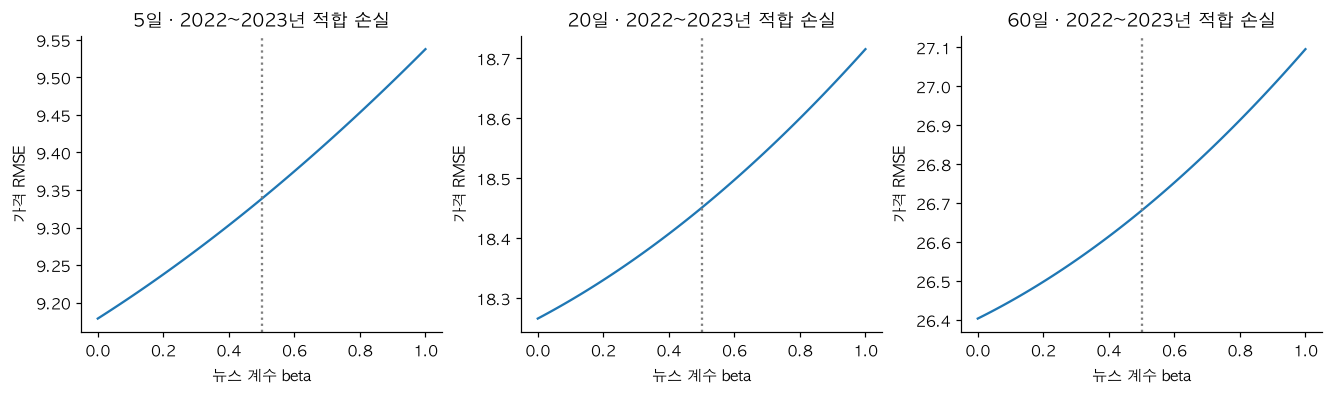

계수는 **실제 가격 − 기본 모델 예측 가격**에 맞춰 적합한다. bullish 뉴스가 실제 상승을 맞춰도 기본 모델이 이미 실제보다 높은 가격을 예측했다면 양의 뉴스 보정은 오차를 키운다. 0 부근의 손실 기울기가 양수이면 beta를 늘리는 것이 손실을 키운다. 방향 일치율만으로 최적 계수를 정하지는 않으며, 위 손실에는 가격 오차 크기도 반영된다. 2022~2023년 402기사 중 새 규칙의 방향 신호는 77건(상승 55/하락 22), 나머지 325건은 0이다. 이 77기사의 영향이 감쇠·시차로 여러 예측일에 남을 수 있으므로 뉴스 유효 예측일 수와 기사 수를 구분한다. 제목만으로 수행한 소급 분류와 작은 방향 표본은 한계이며, 0 계수만으로 뉴스가 무가치하거나 반대로 읽어야 한다고 결론내리지 않는다.

In [4]:
raw=pd.read_parquet(CACHE,filters=[("split","==","validation")])
raw=raw.loc[raw.origin_date.ge("2022-02-01") & raw.model.isin({m for members in PAIRS.values() for m in members})].copy()
assert raw.target_date.le(FINAL_CUTOFF).all() and raw.origin_date.dt.year.isin([2022,2023]).all()
assert (raw.train_cutoff<raw.origin_date).all()
assert not raw.duplicated(["fold","horizon","model","setting","origin_date"]).any()
settings,panels,base_members={}, {}, {}
setting_rows=[]
for h,members in PAIRS.items():
    for name in members:
        candidates=[]
        for setting,g in raw.loc[raw.horizon.eq(h)&raw.model.eq(name)&raw.fold.eq("2022")].groupby("setting"):
            candidates.append({"지평":h,"모델":name,"설정":int(setting),**scores(g,g.predicted_return)})
        table=pd.DataFrame(candidates).sort_values(["가격 RMSE","설정"])
        settings[h,name]=int(table.iloc[0]["설정"]);setting_rows.extend(candidates)
    selected=pd.concat([raw.loc[raw.horizon.eq(h)&raw.model.eq(name)&raw.setting.eq(settings[h,name])] for name in members])
    for year in (2022,2023):
        r,p=align_models(selected.loc[selected.fold.eq(str(year))],members)
        panels[year,h]=(with_news(r,h),p)
    base_members[h]={name:(name,) for name in members}
    if len(members)>1:base_members[h][" + ".join(members)]=members
show(pd.DataFrame(setting_rows))
print("2022년 설정:",settings)
validation_rows,fit_rows,frozen_coefficients,selection_rows=[],[],{},[]
for h in PAIRS:
    dev,dp=panels[2022,h];valid,vp=panels[2023,h]
    for base,members in base_members[h].items():
        fitted=fit_strength(dev,average_prices(dp[list(members)]),"2022-12-31")
        fit_rows.append({"지평":h,"모델":base,"적합":"2022 개발",**fitted})
        for mode,beta in (("뉴스 없음",0.),("초기 0.5 고정",.5),("뉴스 학습",fitted["beta"])):
            pred=adjust(average_prices(vp[list(members)]),valid.news_x,beta)
            validation_rows.append({"지평":h,"모델":base,"뉴스":mode,"구성원 수":len(members),"beta":beta,**scores(valid,pred)})
        combined=pd.concat([dev,valid]);combined_predictions=pd.concat([dp,vp])
        final=fit_strength(combined,average_prices(combined_predictions[list(members)]),FINAL_CUTOFF)
        frozen_coefficients[h,base]=final
        fit_rows.append({"지평":h,"모델":base,"적합":"2022~2023 최종",**final})
    table=pd.DataFrame(validation_rows).loc[lambda d:d["지평"].eq(h)].copy()
    single=table.loc[table["구성원 수"].eq(1)&table["뉴스"].eq("뉴스 없음")]
    rmse_reference=single["가격 RMSE"].min();direction_reference=single["균형 정확도 (%)"].max()
    table["상대 오차 합"]=table["가격 RMSE"]/rmse_reference+(1-table["균형 정확도 (%)"]/100)/(1-direction_reference/100)
    eligible=table.loc[~table["뉴스"].eq("초기 0.5 고정")].copy()
    eligible["뉴스 순서"]=eligible["뉴스"].map({"뉴스 없음":0,"뉴스 학습":1})
    best=eligible.sort_values(["상대 오차 합","가격 RMSE","뉴스 순서","구성원 수","모델"]).iloc[0]
    selection_rows.append(best.to_dict())
validation=pd.DataFrame(validation_rows);fit_table=pd.DataFrame(fit_rows);selection=pd.DataFrame(selection_rows)
show(validation)
show(selection[["지평","모델","뉴스","가격 RMSE","균형 정확도 (%)","상대 오차 합"]])
show(fit_table[["지평","모델","적합","initial_beta","beta","fit_rows","fit_max_target","path","gradient_at_zero"]])
protocol={"signal_definition":SIGNAL_DEFINITION,"seed":SEED,"selection_cutoff":"2023-12-31",
    "features":FEATURES,"constant_excluded":constant,"hashes":hashes,"versions":versions,
    "settings":[{"horizon":h,"model":m,"setting":v} for (h,m),v in settings.items()],
    "selected":selection[["지평","모델","뉴스"]].to_dict("records"),
    "coefficients":[{"horizon":h,"model":m,**v} for (h,m),v in frozen_coefficients.items()]}
serialized=json.dumps(protocol,ensure_ascii=False,indent=2,allow_nan=False)
protocol_path=OUTPUT/"frozen_protocol.json"
if protocol_path.exists():assert protocol_path.read_text()==serialized,"고정 프로토콜 충돌"
else:protocol_path.write_text(serialized)
print("평가 전에 2022~2023 선택과 최종 계수를 고정·저장했습니다.")

# 계수가 0인 이유를 평가 기간이 아닌 적합 자료에서 확인한다.
coefficient_diagnostics,curve_rows=[],[]
fig,axes=plt.subplots(1,3,figsize=(12,3.5),constrained_layout=True)
for ax,(h,members) in zip(axes,PAIRS.items()):
    target=" + ".join(members)
    dev,dp=panels[2022,h];valid,vp=panels[2023,h]
    r=pd.concat([dev,valid]);p=pd.concat([dp,vp])
    base=average_prices(p[list(members)])
    actual_price=r.current_price.to_numpy()*np.exp(r.actual_return.to_numpy())
    base_price=r.current_price.to_numpy()*np.exp(base)
    residual=actual_price-base_price
    active=r.news_x.to_numpy()!=0
    curve=[scores(r,adjust(base,r.news_x,b))["가격 RMSE"] for b in np.linspace(0,1,101)]
    for b,rmse in zip(np.linspace(0,1,101),curve):
        curve_rows.append({"지평":h,"모델":target,"beta":b,"적합 가격 RMSE":rmse})
    coefficient_diagnostics.append({"지평":h,"모델":target,"뉴스가 남은 예측일":int(active.sum()),
        "전체 적합일":len(r),"beta 0.5 RMSE 증가 (%)":100*(curve[50]/curve[0]-1),
        "뉴스-실제 변화 방향 일치 (%)":100*np.mean(np.sign(r.news_x.to_numpy()[active])==np.sign(r.actual_return.to_numpy()[active])),
        "뉴스-모델 잔차 방향 일치 (%)":100*np.mean(np.sign(r.news_x.to_numpy()[active])==np.sign(residual[active])),
        "격자 최저 beta":float(np.linspace(0,1,101)[np.argmin(curve)])})
    ax.plot(np.linspace(0,1,101),curve);ax.axvline(.5,linestyle=":",color="gray")
    ax.set(title=f"{h}일 · 2022~2023년 적합 손실",xlabel="뉴스 계수 beta",ylabel="가격 RMSE")
show(pd.DataFrame(coefficient_diagnostics))
coefficient_curve=pd.DataFrame(curve_rows)
plt.show()
display(Markdown("계수는 **실제 가격 − 기본 모델 예측 가격**에 맞춰 적합한다. bullish 뉴스가 실제 상승을 맞춰도 "
    "기본 모델이 이미 실제보다 높은 가격을 예측했다면 양의 뉴스 보정은 오차를 키운다. "
    "0 부근의 손실 기울기가 양수이면 beta를 늘리는 것이 손실을 키운다. "
    "방향 일치율만으로 최적 계수를 정하지는 않으며, 위 손실에는 가격 오차 크기도 반영된다. "
    "2022~2023년 402기사 중 새 규칙의 방향 신호는 77건(상승 55/하락 22), 나머지 325건은 0이다. "
    "이 77기사의 영향이 감쇠·시차로 여러 예측일에 남을 수 있으므로 뉴스 유효 예측일 수와 기사 수를 구분한다. "
    "제목만으로 수행한 소급 분류와 작은 방향 표본은 한계이며, 0 계수만으로 뉴스가 무가치하거나 반대로 읽어야 한다고 결론내리지 않는다."))


## 4. 고정 모델로 2024~2026년 예측

이 셀에서 처음 평가 구간의 모델 예측을 생성한다. 가격 모델의 가중치·입력 표준화·기후 기준값·target 표준화 모두 2023년 말까지의 자료로 고정한다. 평가 중 연도별 재학습이나 계수 갱신은 없다. 기존 서비스의 가격+거시 7개 artifact 대신, 이 연구의 **동일한 가격+거시+기후 27개 입력**으로 지정 모델 5개(모델×지평)를 학습한다. 뉴스 계수와 선택은 위 고정 파일에서 가져온다.

In [5]:
assert protocol_path.read_text()==serialized
model_dir=OUTPUT/"models";model_dir.mkdir(exist_ok=True)
parts=[]
for (h,name),setting in settings.items():
    start=time.monotonic()
    part=forecast(sources,sessions,FEATURES,h,name,setting,model_dir/f"{name}_{h}")
    parts.append(part)
    print(f"{h}일 {name}: {len(part)}건 · {time.monotonic()-start:.1f}초",flush=True)
base_predictions=pd.concat(parts,ignore_index=True)
assert base_predictions.train_cutoff.eq(FINAL_CUTOFF).all()
assert base_predictions.origin_date.dt.year.isin([2024,2025,2026]).all()
# 과거 동일 설정의 저장 예측과 겹치는 날짜에서 재학습 재현성을 대조한다.
old=pd.read_parquet(CACHE,filters=[("split","==","historical")])
reproduction=[]
for (h,name),g in base_predictions.groupby(["horizon","model"]):
    previous=old.loc[old.horizon.eq(h)&old.model.eq(name)&old.setting.eq(settings[h,name])]
    matched=g.merge(previous,on=["origin_date","horizon","model","setting"],suffixes=("_new","_old"))
    if not matched.empty:
        np.testing.assert_allclose(matched.predicted_return_new,matched.predicted_return_old,atol=2e-6,rtol=1e-5)
    reproduction.append({"지평":h,"모델":name,"동일 설정 대조 건수":len(matched)})
show(pd.DataFrame(reproduction),0)
forecast_rows,metric_rows=[] ,[]
for h,members in PAIRS.items():
    r,p=align_models(base_predictions.loc[base_predictions.horizon.eq(h)],members);r=with_news(r,h)
    selected=selection.loc[selection["지평"].eq(h)].iloc[0]
    for base,names in base_members[h].items():
        base_prediction=average_prices(p[list(names)])
        for mode,beta in (("뉴스 없음",0.),("초기 0.5 고정",.5),("뉴스 학습",frozen_coefficients[h,base]["beta"])):
            prediction=adjust(base_prediction,r.news_x,beta)
            selected_flag=base==selected["모델"] and mode==selected["뉴스"]
            out=r.assign(horizon=h,model=base,news_mode=mode,beta=beta,base_return=base_prediction,
                         predicted_return=prediction,selected=selected_flag).reset_index()
            forecast_rows.append(out)
            for year,mask in [("전체",np.ones(len(r),dtype=bool)),*[(str(y),r.index.year==y) for y in (2024,2025,2026)]]:
                if not mask.any():continue
                metric_rows.append({"연도":year,"지평":h,"모델":base,"뉴스":mode,"beta":beta,"Validation 선택":selected_flag,
                    "예측 시작":r.index[mask].min().date(),"예측 끝":r.index[mask].max().date(),
                    "정답 끝":r.target_date.loc[mask].max().date(),**scores(r.loc[mask],prediction[mask])})
forecasts=pd.concat(forecast_rows,ignore_index=True);metrics=pd.DataFrame(metric_rows)
show(metrics.loc[metrics["연도"].eq("전체")])
show(metrics.loc[metrics["Validation 선택"]&~metrics["연도"].eq("전체")])

5일 NLinear: 682건 · 3.2초


5일 XGBoost: 682건 · 7.8초


20일 NLinear: 667건 · 0.3초


20일 DLinear: 667건 · 0.6초


60일 DLinear: 627건 · 0.6초


|   지평 | 모델    |   동일 설정 대조 건수 |
|-------:|:--------|----------------------:|
|      5 | NLinear |                   498 |
|      5 | XGBoost |                   498 |
|     20 | DLinear |                   483 |
|     20 | NLinear |                   483 |
|     60 | DLinear |                   443 |

| 연도   |   지평 | 모델              | 뉴스          |   beta | Validation 선택   | 예측 시작   | 예측 끝    | 정답 끝    |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|:-------|-------:|:------------------|:--------------|-------:|:------------------|:------------|:-----------|:-----------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
| 전체   |      5 | NLinear           | 뉴스 없음     | 0.0000 | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.1413 |        0.0567 |           50.8798 |           50.8057 |           43.3428 |
| 전체   |      5 | NLinear           | 초기 0.5 고정 | 0.5000 | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.2889 |        0.0571 |           48.0938 |           47.5626 |           34.8442 |
| 전체   |      5 | NLinear           | 뉴스 학습     | 0.0000 | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.1413 |        0.0567 |           50.8798 |           50.8057 |           43.3428 |
| 전체   |      5 | XGBoost           | 뉴스 없음     | 0.0000 | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.6151 |        0.0578 |           49.4135 |           48.9838 |           35.9773 |
| 전체   |      5 | XGBoost           | 초기 0.5 고정 | 0.5000 | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.6685 |        0.0580 |           51.1730 |           50.4695 |           27.1955 |
| 전체   |      5 | XGBoost           | 뉴스 학습     | 0.0000 | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.6151 |        0.0578 |           49.4135 |           48.9838 |           35.9773 |
| 전체   |      5 | NLinear + XGBoost | 뉴스 없음     | 0.0000 | True              | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.2001 |        0.0566 |           50.1466 |           49.9173 |           40.2266 |
| 전체   |      5 | NLinear + XGBoost | 초기 0.5 고정 | 0.5000 | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.2994 |        0.0569 |           51.7595 |           51.0699 |           26.9122 |
| 전체   |      5 | NLinear + XGBoost | 뉴스 학습     | 0.0000 | False             | 2024-01-02  | 2026-09-18 | 2026-09-25 |    682 |     18.2001 |        0.0566 |           50.1466 |           49.9173 |           40.2266 |
| 전체   |     20 | NLinear           | 뉴스 없음     | 0.0000 | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     39.0695 |        0.1232 |           53.9730 |           52.9576 |           39.2573 |
| 전체   |     20 | NLinear           | 초기 0.5 고정 | 0.5000 | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     40.0447 |        0.1255 |           52.0240 |           50.1592 |           35.5438 |
| 전체   |     20 | NLinear           | 뉴스 학습     | 0.0000 | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     39.0695 |        0.1232 |           53.9730 |           52.9576 |           39.2573 |
| 전체   |     20 | DLinear           | 뉴스 없음     | 0.0000 | True              | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     36.8419 |        0.1157 |           54.4228 |           55.3448 |           51.7241 |
| 전체   |     20 | DLinear           | 초기 0.5 고정 | 0.5000 | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     36.9105 |        0.1158 |           56.6717 |           56.8170 |           44.2971 |
| 전체   |     20 | DLinear           | 뉴스 학습     | 0.0000 | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     36.8419 |        0.1157 |           54.4228 |           55.3448 |           51.7241 |
| 전체   |     20 | NLinear + DLinear | 뉴스 없음     | 0.0000 | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     37.1836 |        0.1171 |           54.2729 |           54.2175 |           45.3581 |
| 전체   |     20 | NLinear + DLinear | 초기 0.5 고정 | 0.5000 | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     37.7176 |        0.1184 |           56.3718 |           55.6764 |           38.9920 |
| 전체   |     20 | NLinear + DLinear | 뉴스 학습     | 0.0000 | False             | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |     37.1836 |        0.1171 |           54.2729 |           54.2175 |           45.3581 |
| 전체   |     60 | DLinear           | 뉴스 없음     | 0.0000 | True              | 2024-01-02  | 2026-07-01 | 2026-09-25 |    627 |     48.5478 |        0.1518 |           81.8182 |           81.5187 |           17.5182 |
| 전체   |     60 | DLinear           | 초기 0.5 고정 | 0.5000 | False             | 2024-01-02  | 2026-07-01 | 2026-09-25 |    627 |     47.9707 |        0.1502 |           80.2233 |           79.2038 |           17.5182 |
| 전체   |     60 | DLinear           | 뉴스 학습     | 0.0000 | False             | 2024-01-02  | 2026-07-01 | 2026-09-25 |    627 |     48.5478 |        0.1518 |           81.8182 |           81.5187 |           17.5182 |

|   연도 |   지평 | 모델              | 뉴스      |   beta | Validation 선택   | 예측 시작   | 예측 끝    | 정답 끝    |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|-------:|-------:|:------------------|:----------|-------:|:------------------|:------------|:-----------|:-----------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
|   2024 |      5 | NLinear + XGBoost | 뉴스 없음 | 0.0000 | True              | 2024-01-02  | 2024-12-31 | 2025-01-08 |    252 |     11.9466 |        0.0489 |           56.3492 |           52.1194 |           21.2329 |
|   2025 |      5 | NLinear + XGBoost | 뉴스 없음 | 0.0000 | True              | 2025-01-02  | 2025-12-31 | 2026-01-08 |    251 |     22.8238 |        0.0623 |           43.0279 |           44.2599 |           70.4545 |
|   2026 |      5 | NLinear + XGBoost | 뉴스 없음 | 0.0000 | True              | 2026-01-02  | 2026-09-18 | 2026-09-25 |    179 |     18.1843 |        0.0582 |           51.3966 |           54.8269 |           24.0000 |
|   2024 |     20 | DLinear           | 뉴스 없음 | 0.0000 | True              | 2024-01-02  | 2024-12-31 | 2025-01-30 |    252 |     25.7875 |        0.0994 |           47.6190 |           43.6596 |           46.9274 |
|   2025 |     20 | DLinear           | 뉴스 없음 | 0.0000 | True              | 2025-01-02  | 2025-12-31 | 2026-01-30 |    251 |     43.6971 |        0.1215 |           60.1594 |           58.0782 |           72.6496 |
|   2026 |     20 | DLinear           | 뉴스 없음 | 0.0000 | True              | 2026-01-02  | 2026-08-27 | 2026-09-25 |    164 |     39.7006 |        0.1289 |           56.0976 |           56.2398 |           32.0988 |
|   2024 |     60 | DLinear           | 뉴스 없음 | 0.0000 | True              | 2024-01-02  | 2024-12-31 | 2025-03-28 |    252 |     58.3888 |        0.1886 |           81.7460 |           51.4980 |           17.0040 |
|   2025 |     60 | DLinear           | 뉴스 없음 | 0.0000 | True              | 2025-01-02  | 2025-12-31 | 2026-03-30 |    251 |     46.0390 |        0.1347 |           86.0558 |           83.8762 |           28.8462 |
|   2026 |     60 | DLinear           | 뉴스 없음 | 0.0000 | True              | 2026-01-02  | 2026-07-01 | 2026-09-25 |    124 |     26.4299 |        0.0873 |           73.3871 |           74.2188 |            0.0000 |

## 5. 지정 조합의 뉴스 추가 효과와 단일 모델 대조

모든 숫자는 같은 지평·동일 날짜의 비교다. 뉴스 추가 효과는 같은 기본 예측의 뉴스 없는 대조군과 비교한다. 지정 조합은 각 구성 단일 모델과 각각 대조한다. 평가 구간에서 더 좋아 보이는 모델을 다시 선택하지 않는다. 원두 매입비·재고·품절은 별도 수요/비용 자료가 없으므로 가격·방향 지표를 실제 재고관리 성과로 부르지 않는다.

| 연도   |   지평 | 지정 조합         | 비교 모델         | 비교 뉴스   |   뉴스 beta |   조합 RMSE |   비교 RMSE |   RMSE 개선 (%) |   균형 변화 (pp) |
|:-------|-------:|:------------------|:------------------|:------------|------------:|------------:|------------:|----------------:|-----------------:|
| 전체   |      5 | NLinear + XGBoost | NLinear + XGBoost | 뉴스 없음   |      0.0000 |     18.2001 |     18.2001 |          0.0000 |           0.0000 |
| 전체   |      5 | NLinear + XGBoost | NLinear           | 뉴스 없음   |      0.0000 |     18.2001 |     18.1413 |         -0.3238 |          -0.8884 |
| 전체   |      5 | NLinear + XGBoost | XGBoost           | 뉴스 없음   |      0.0000 |     18.2001 |     18.6151 |          2.2296 |           0.9335 |
| 전체   |      5 | NLinear + XGBoost | NLinear           | 뉴스 학습   |      0.0000 |     18.2001 |     18.1413 |         -0.3238 |          -0.8884 |
| 전체   |      5 | NLinear + XGBoost | XGBoost           | 뉴스 학습   |      0.0000 |     18.2001 |     18.6151 |          2.2296 |           0.9335 |
| 전체   |     20 | NLinear + DLinear | NLinear + DLinear | 뉴스 없음   |      0.0000 |     37.1836 |     37.1836 |          0.0000 |           0.0000 |
| 전체   |     20 | NLinear + DLinear | NLinear           | 뉴스 없음   |      0.0000 |     37.1836 |     39.0695 |          4.8272 |           1.2599 |
| 전체   |     20 | NLinear + DLinear | DLinear           | 뉴스 없음   |      0.0000 |     37.1836 |     36.8419 |         -0.9275 |          -1.1273 |
| 전체   |     20 | NLinear + DLinear | NLinear           | 뉴스 학습   |      0.0000 |     37.1836 |     39.0695 |          4.8272 |           1.2599 |
| 전체   |     20 | NLinear + DLinear | DLinear           | 뉴스 학습   |      0.0000 |     37.1836 |     36.8419 |         -0.9275 |          -1.1273 |
| 전체   |     60 | DLinear           | DLinear           | 뉴스 없음   |      0.0000 |     48.5478 |     48.5478 |          0.0000 |           0.0000 |

|   지평 | 지정 조합         | 비교 모델         | 비교 뉴스   |   블록 |   가격 MSE 개선 |   95% 하한 |   95% 상한 |
|-------:|:------------------|:------------------|:------------|-------:|----------------:|-----------:|-----------:|
|      5 | NLinear + XGBoost | NLinear + XGBoost | 뉴스 없음   |      5 |          0.0000 |     0.0000 |     0.0000 |
|      5 | NLinear + XGBoost | NLinear + XGBoost | 뉴스 없음   |     10 |          0.0000 |     0.0000 |     0.0000 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 없음   |      5 |         -2.1348 |   -14.0948 |     8.5615 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 없음   |     10 |         -2.1348 |   -15.6417 |    10.7066 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 없음   |      5 |         15.2800 |     4.4530 |    27.5383 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 없음   |     10 |         15.2800 |     2.1800 |    29.3358 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 학습   |      5 |         -2.1348 |   -14.0948 |     8.5615 |
|      5 | NLinear + XGBoost | NLinear           | 뉴스 학습   |     10 |         -2.1348 |   -15.6417 |    10.7066 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 학습   |      5 |         15.2800 |     4.4530 |    27.5383 |
|      5 | NLinear + XGBoost | XGBoost           | 뉴스 학습   |     10 |         15.2800 |     2.1800 |    29.3358 |
|     20 | NLinear + DLinear | NLinear + DLinear | 뉴스 없음   |     20 |          0.0000 |     0.0000 |     0.0000 |
|     20 | NLinear + DLinear | NLinear + DLinear | 뉴스 없음   |     40 |          0.0000 |     0.0000 |     0.0000 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 없음   |     20 |        143.8110 |     3.5919 |   298.3485 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 없음   |     40 |        143.8110 |     4.3990 |   312.5335 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 없음   |     20 |        -25.2940 |  -177.4822 |   119.3876 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 없음   |     40 |        -25.2940 |  -185.9127 |   122.7772 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 학습   |     20 |        143.8110 |     3.5919 |   298.3485 |
|     20 | NLinear + DLinear | NLinear           | 뉴스 학습   |     40 |        143.8110 |     4.3990 |   312.5335 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 학습   |     20 |        -25.2940 |  -177.4822 |   119.3876 |
|     20 | NLinear + DLinear | DLinear           | 뉴스 학습   |     40 |        -25.2940 |  -185.9127 |   122.7772 |
|     60 | DLinear           | DLinear           | 뉴스 없음   |     60 |          0.0000 |     0.0000 |     0.0000 |
|     60 | DLinear           | DLinear           | 뉴스 없음   |    120 |          0.0000 |     0.0000 |     0.0000 |

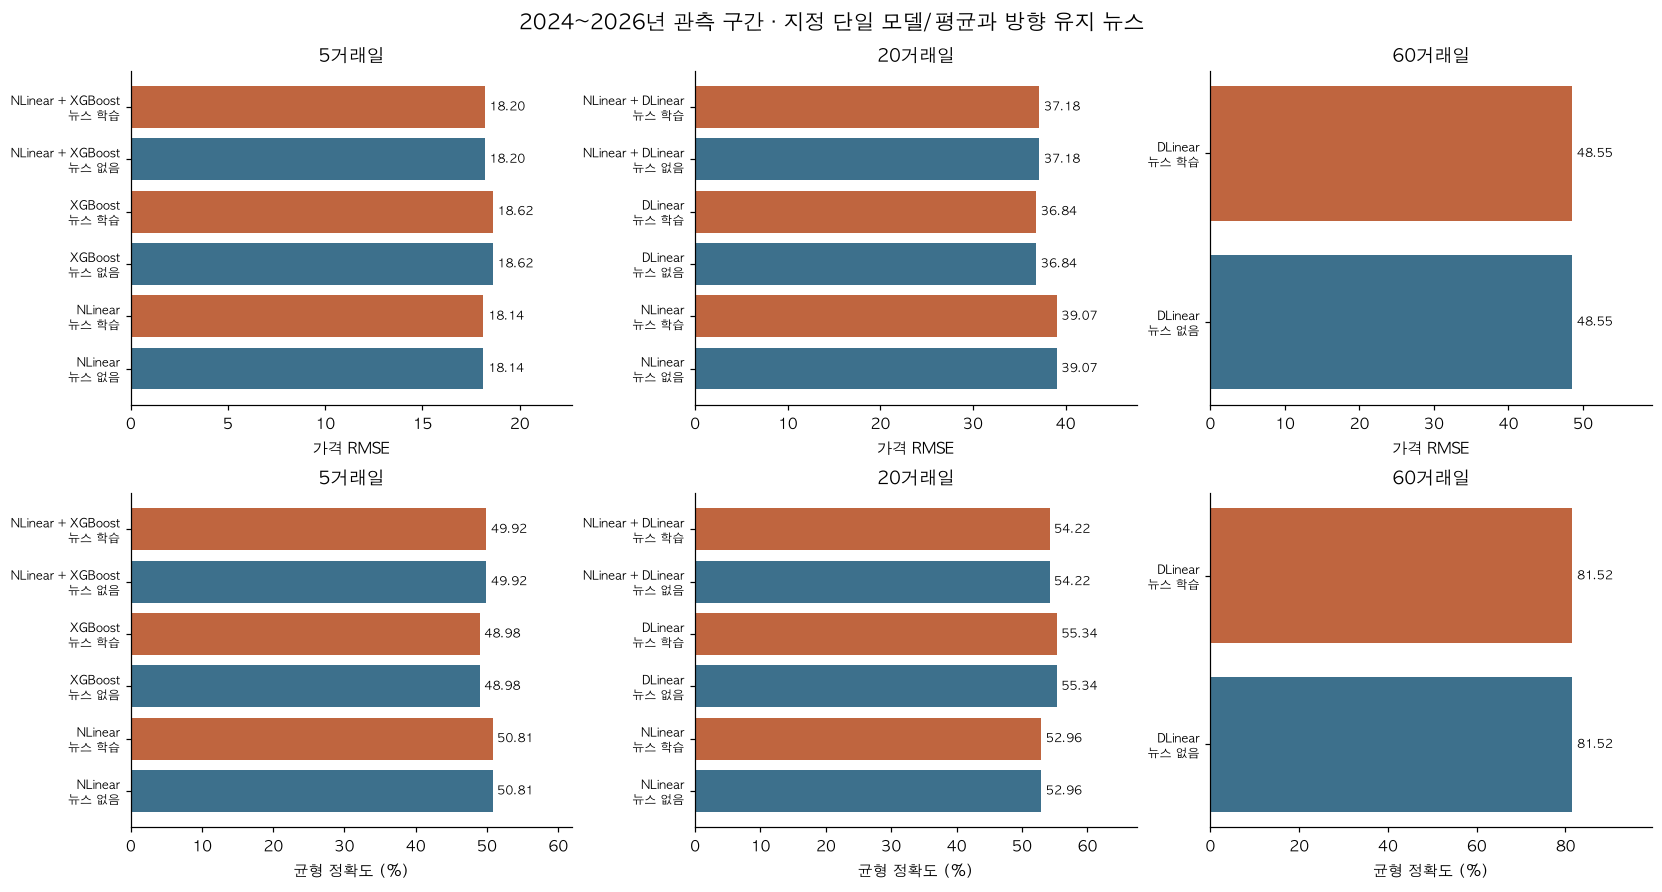

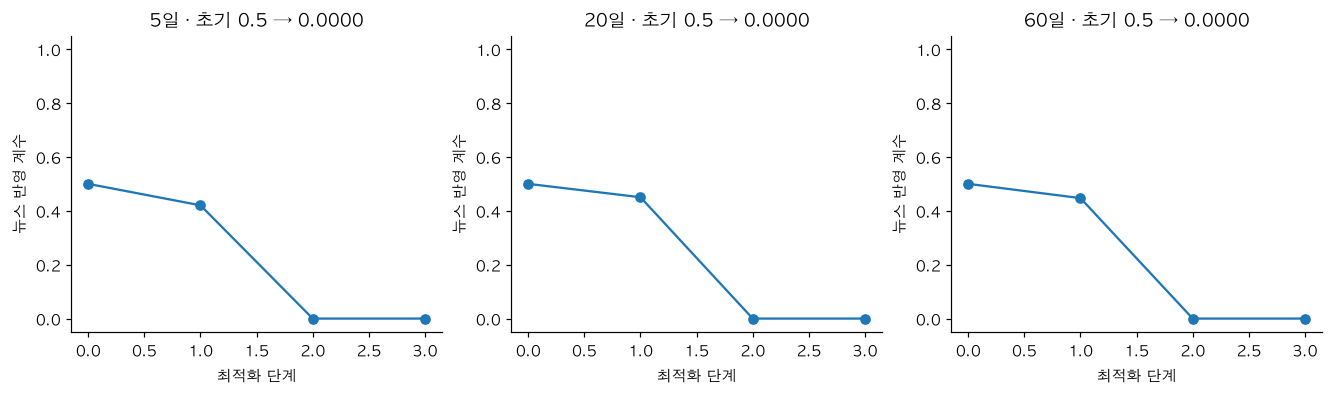

In [6]:
comparison_rows,interval_rows=[] ,[]
for h,members in PAIRS.items():
    target=" + ".join(members)
    table=forecasts.loc[forecasts.horizon.eq(h)]
    def prediction(base,mode):
        return table.loc[table.model.eq(base)&table.news_mode.eq(mode)].set_index("origin_date").sort_index()
    candidate=prediction(target,"뉴스 학습")
    comparators=[(target,"뉴스 없음"),*[(m,"뉴스 없음") for m in members if m!=target],
                 *[(m,"뉴스 학습") for m in members if m!=target]]
    for base,mode in comparators:
        reference=prediction(base,mode)
        pd.testing.assert_index_equal(candidate.index,reference.index)
        pd.testing.assert_frame_equal(candidate[["actual_return","current_price","target_date"]],reference[["actual_return","current_price","target_date"]])
        for year,mask in [("전체",np.ones(len(candidate),dtype=bool)),*[(str(y),candidate.index.year==y) for y in (2024,2025,2026)]]:
            if not mask.any():continue
            a=scores(candidate.loc[mask],candidate.predicted_return.loc[mask]);b=scores(reference.loc[mask],reference.predicted_return.loc[mask])
            comparison_rows.append({"연도":year,"지평":h,"지정 조합":target,"비교 모델":base,"비교 뉴스":mode,
                "뉴스 beta":frozen_coefficients[h,target]["beta"],"조합 RMSE":a["가격 RMSE"],"비교 RMSE":b["가격 RMSE"],
                "RMSE 개선 (%)":100*(1-a["가격 RMSE"]/b["가격 RMSE"]),
                "균형 변화 (pp)":a["균형 정확도 (%)"]-b["균형 정확도 (%)"]})
        # Eligible forecast windows are not necessarily contiguous after missing input windows.
        # Use calendar trading-session positions for block sampling, with gaps explicitly checked.
        assert candidate.index.equals(coffee_sessions(candidate.index.min(),candidate.index.max())),"평가 거래일 공백: 블록 정의를 수정해야 함"
        for block in (h,2*h):
            interval_rows.append({"지평":h,"지정 조합":target,"비교 모델":base,"비교 뉴스":mode,"블록":block,
                **paired_interval(candidate,candidate.predicted_return,reference.predicted_return,block)})
comparisons=pd.DataFrame(comparison_rows);intervals=pd.DataFrame(interval_rows)
show(comparisons.loc[comparisons["연도"].eq("전체")])
show(intervals)
fig,axes=plt.subplots(2,3,figsize=(15,8),constrained_layout=True)
for column,(h,members) in enumerate(PAIRS.items()):
    table=metrics.loc[metrics["연도"].eq("전체")&metrics["지평"].eq(h)&~metrics["뉴스"].eq("초기 0.5 고정")]
    labels=[f"{row['모델']}\n{row['뉴스']}" for row in table.to_dict("records")]
    for ax,metric in zip(axes[:,column],["가격 RMSE","균형 정확도 (%)"]):
        bars=ax.barh(range(len(table)),table[metric],color=["#BF653F" if mode=="뉴스 학습" else "#3D708C" for mode in table["뉴스"]])
        ax.set(yticks=range(len(table)),yticklabels=labels,xlabel=metric,title=f"{h}거래일")
        ax.tick_params(axis="y",labelsize=8);ax.bar_label(bars,fmt="%.2f",padding=3,fontsize=8)
        ax.set_xlim(0,table[metric].max()*1.22)
fig.suptitle("2024~2026년 관측 구간 · 지정 단일 모델/평균과 방향 유지 뉴스",fontsize=14)
plt.show()
fig,axes=plt.subplots(1,3,figsize=(12,3.5),constrained_layout=True)
for ax,(h,members) in zip(axes,PAIRS.items()):
    target=" + ".join(members)
    fit=fit_table.loc[fit_table["지평"].eq(h)&fit_table["모델"].eq(target)&fit_table["적합"].eq("2022~2023 최종")].iloc[0]
    ax.plot(range(len(fit.path)),fit.path,marker="o");ax.set(ylim=(-.05,1.05),title=f"{h}일 · 초기 0.5 → {fit.beta:.4f}",xlabel="최적화 단계",ylabel="뉴스 반영 계수")
plt.show()

## 6. 실행 검사와 결과 저장

초기값·뉴스 방향·미래 기사 불변성·정답 성숙도를 검사하고 예측/선택/계수/피처 목록을 저장한다. 결과 파일은 입력·코드·의존성 버전별로 구분하며 동일 run의 재실행 값이 다르면 충돌로 중단한다. 모델 가중치와 표준화 파라미터도 연구 run의 `models/`에 보관하고 저장 후 다시 읽은 모델의 예측 일치를 검사한다. 저장 파일과 그림은 새로운 실시간 거래 전략의 검증을 뜻하지 않는다.

In [7]:
assert not forecasts.duplicated(["horizon","model","news_mode","origin_date"]).any()
assert not forecasts.model.str.contains("Persistence|Naive",regex=True).any()
assert forecasts.target_date.le(prices.close.dropna().index.max()).all()
assert forecasts.origin_date.dt.year.isin([2024,2025,2026]).all()
assert fit_table.initial_beta.eq(.5).all() and fit_table.beta.between(0,1).all()
assert pd.to_datetime(fit_table.fit_max_target).le(FINAL_CUTOFF).all()
np.testing.assert_allclose(forecasts.predicted_return-forecasts.base_return,forecasts.beta*forecasts.news_x,atol=1e-15)
# 미래 기사 추가가 과거 신호를 바꾸면 안 된다.
probe=news_sessions[:40];boundary=probe[-1].tz_localize("UTC")+pd.Timedelta(hours=23)
earlier=[r for r in records if pd.Timestamp(r["event_at"])<=boundary and pd.Timestamp(r["selection_available_at"])<=boundary]
pd.testing.assert_frame_equal(signal_features(earlier,probe,availability="research"),features.loc[probe])
for (h,name),setting in settings.items():
    z=np.load(model_dir/f"{name}_{h}.npz")
    assert z["features"].tolist()==FEATURES and str(z["train_cutoff"])=="2023-12-31"
for filename,frame in {"individual_predictions.parquet":forecasts,"base_predictions.parquet":base_predictions,
    "metrics.csv":metrics,"comparisons.csv":comparisons,"validation.csv":validation,"coefficients.csv":fit_table,
    "intervals.csv":intervals,"coefficient_curve.csv":coefficient_curve,"feature_audit.csv":feature_audit,"news_audit.csv":news_audit}.items():
    path=OUTPUT/filename
    if path.suffix==".parquet":
        if path.exists():pd.testing.assert_frame_equal(pd.read_parquet(path),frame,check_exact=True)
        else:frame.to_parquet(path,index=False)
    else:
        content=frame.to_csv(index=False)
        if path.exists():assert path.read_text()==content,f"재실행 값 충돌: {filename}"
        else:path.write_text(content)
print("검사 통과 및 저장:",OUTPUT.relative_to(ROOT))
for h,members in PAIRS.items():
    target=" + ".join(members);beta=frozen_coefficients[h,target]["beta"]
    row=metrics.loc[metrics["연도"].eq("전체")&metrics["지평"].eq(h)&metrics["모델"].eq(target)&metrics["뉴스"].eq("뉴스 학습")].iloc[0]
    choice=selection.loc[selection["지평"].eq(h)].iloc[0]
    effect=comparisons.loc[comparisons["연도"].eq("전체")&comparisons["지평"].eq(h)&comparisons["비교 모델"].eq(target)&comparisons["비교 뉴스"].eq("뉴스 없음")].iloc[0]
    display(Markdown(f"**{h}일 지정 후보:** {target}, beta={beta:.4f}. 평가 RMSE {row['가격 RMSE']:.4f}, "
        f"방향 {row['방향 적중률 (%)']:.2f}%, 균형 {row['균형 정확도 (%)']:.2f}%. "
        f"뉴스만의 RMSE 개선 {effect['RMSE 개선 (%)']:+.2f}%, 균형 변화 {effect['균형 변화 (pp)']:+.2f}pp. "
        f"Validation에서 선택한 것은 **{choice['모델']} / {choice['뉴스']}**이며 평가 결과로 재선택하지 않았다."))
display(Markdown("**결론의 한계:** 초기 0.5에서 출발해도 최종 0은 가능하며 이는 초기화 실패와 다르다. "
    "소급 뉴스·이미 본 평가 구간·제한된 설정·한 seed의 결과다. 개선 여부는 단일 모델 대비와 뉴스 대조군 대비를 각각 읽는다. "
    "블록 구간은 고정 예측에 조건부이며 모델/규칙 선택과 소급 분류의 불확실성을 포함하지 않는다."))

검사 통과 및 저장: data/processed/fixed_ensemble_news/a0b224ef6e71cbae


**5일 지정 후보:** NLinear + XGBoost, beta=0.0000. 평가 RMSE 18.2001, 방향 50.15%, 균형 49.92%. 뉴스만의 RMSE 개선 +0.00%, 균형 변화 +0.00pp. Validation에서 선택한 것은 **NLinear + XGBoost / 뉴스 없음**이며 평가 결과로 재선택하지 않았다.

**20일 지정 후보:** NLinear + DLinear, beta=0.0000. 평가 RMSE 37.1836, 방향 54.27%, 균형 54.22%. 뉴스만의 RMSE 개선 +0.00%, 균형 변화 +0.00pp. Validation에서 선택한 것은 **DLinear / 뉴스 없음**이며 평가 결과로 재선택하지 않았다.

**60일 지정 후보:** DLinear, beta=0.0000. 평가 RMSE 48.5478, 방향 81.82%, 균형 81.52%. 뉴스만의 RMSE 개선 +0.00%, 균형 변화 +0.00pp. Validation에서 선택한 것은 **DLinear / 뉴스 없음**이며 평가 결과로 재선택하지 않았다.

**결론의 한계:** 초기 0.5에서 출발해도 최종 0은 가능하며 이는 초기화 실패와 다르다. 소급 뉴스·이미 본 평가 구간·제한된 설정·한 seed의 결과다. 개선 여부는 단일 모델 대비와 뉴스 대조군 대비를 각각 읽는다. 블록 구간은 고정 예측에 조건부이며 모델/규칙 선택과 소급 분류의 불확실성을 포함하지 않는다.